# 1. Importing necessary libraries and dataset with engineered features

In [42]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf 
from statsmodels.tsa.arima.model import ARIMA
import statsmodels.api as sm
import statsmodels.tsa.api as smtsa
from typing import Union
from tqdm import tqdm
from itertools import product
from statsmodels.stats.diagnostic import acorr_ljungbox
import joblib

%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

In [43]:
#Importing the Dataframe with the features

df = pd.read_csv('/Users/arthurassis/Documents/CCT - Data Analytics for Business/Machine Learning/Semester 2/CA01-MachineLearning-Semester2/CA01-MachineLearning/Python-Forecasting-Electrical-Demand-on-Spain/part_2_output_features_engineered.csv',
                parse_dates = ['timestamp'])

In [44]:
#Setting the timestamp as the index

df.set_index('timestamp', inplace = True)

In [45]:
#Droping the column with TSO Forecasts

df.drop(columns = 'total load forecast', inplace = True)

In [46]:
#Defining a function to calculate MAPE

def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# 2. Training the model

In [47]:
#Creating dummies of the year in the dataset

dummies = pd.get_dummies(df['year'], prefix='year')

# Join back to original DataFrame (drop the original if you like)
df = pd.concat([df.drop('year', axis=1), dummies], axis=1)

In [48]:
#Creating dummies of the season in the dataset

dummies = pd.get_dummies(df['season'], prefix='season')

# Join back to original DataFrame (drop the original if you like)
df = pd.concat([df.drop('season', axis=1), dummies], axis=1)

SARIMAX cannot natively handle multiple seasonalities. However, as the multiple seasonalities have been already identified, it is possible to create a model in which the enconded seasonalities are passed to SARIMAX as exogenous variables, rather than using the seasonal component of the method itself. This way, the seasonal patterns within the data are treated with a regression method, while ARMA takes care of the auto regressive and moving average part of the data.

Another disadvantage of SAMIRAX is that it tends to be slow for a large dataset, such as the one analysed.

The first step for applying SARIMAX is verifying if the time series is stationary. This is done performing an Augment Dickey-Fuller (ADF) Test.

In [50]:
#Perfoming an ADF test to verify stationarity of the data

ad_fuller_result = adfuller(df['total load actual'])

In [51]:
#Printing results

print(f'ADF Statistic: {ad_fuller_result[0]}')
print(f'p-value: {ad_fuller_result[1]}')

ADF Statistic: -21.450782270764343
p-value: 0.0


As p-value is 0 and ADF Statistic is a large negative number, the null hypothesis is rejected and the time series is considered stationary.

As is follows, a function used to optimise the ARIMAX model will be defined.

In [52]:
#Defining a function to optimise SARIMAX model

def optimise_SARIMAX(
    endog: Union[pd.Series, list],
    exog: Union[pd.Series, list, pd.DataFrame, np.ndarray],
    test_endog: Union[pd.Series, list],
    test_exog: Union[pd.Series, list, pd.DataFrame, np.ndarray],
    order_list: list,
    d: int, 
    D: int,
    s: int
) -> pd.DataFrame:

    results = []
    failures = []  # store failed orders and their errors

    for order in tqdm(order_list):
        try:
            model = SARIMAX(
                endog=endog,
                exog=exog,
                order=(order[0], d, order[1]),
                seasonal_order=(order[2], D, order[3], s),
                simple_differencing=False,
                initialization="approximate_diffuse"  # often more robust
            ).fit(disp=False,  # set to True if you want convergence messages
                  method="powell",  # or "bfgs" if you get issues
                  maxiter=200)

            model_result =  model.predict(start=test_endog.index[0],
                                    end = test_endog.index[-1],
                                    exog = test_exog.astype('float64'))
            mape_model = mape(test_endog, model_result)
            aic = model.aic
            results.append([order, aic, mape_model])
            print(f"Success for order {order}; AIC = {aic:.2f}; MAPE_r={mape_model:2f}")

        except Exception as err:
            error_str = f"{type(err).__name__}: {str(err)}"
            failures.append((order, error_str))
            print(f"Failed for order {order}: {error_str}")

    # Safely build result DataFrame even if results is empty
    if len(results) == 0:
        result_df = pd.DataFrame(columns=["(p,q,P,Q)", "AIC", "MAPE"])
        print("Warning: no models converged.")
    else:
        result_df = pd.DataFrame(results, columns=["(p,q,P,Q)", "AIC", "MAPE"])

    result_df = result_df.sort_values(by="AIC", ascending=True).reset_index(drop=True)

    return result_df


In [67]:
#Selecting the values that will be used to optimise the AIC in ARIMAX

ps = range(0,3,1)
qs = range(0,3,1)
Ps = range(0,3,1)
Qs = range(0,3,1)
d = 0
D = 0
s = 24

In [68]:
#Creating all combinations of p, q, P and Q

SARIMA_order_list = list(product(ps, qs, Ps, Qs))

In [69]:
#Printing the columns of df2

df.columns

Index(['total load actual', 'month', 'doy', 'dom', 'dow', 'woy', 'hour',
       'is_leap_year', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos',
       'month_sin', 'month_cos', 'doy_sin', 'doy_cos', 'woy_sin', 'woy_cos',
       'is_weekend', 'is_end_of_year', 'is_christmas', 'is_holiday',
       'year_2015', 'year_2016', 'year_2017', 'year_2018', 'season_Autumn',
       'season_Spring', 'season_Summer', 'season_Winter'],
      dtype='object')

In [395]:
#Defining my train, test and exogenous variables for the method

df_sarimax_train = df.loc['2015-01-01 00:00:00':'2017-10-31 23:00:00']['total load actual']
df_sarimax_test = df.loc['2017-11-01 00:00:00':'2018-04-01 00:00:00']['total load actual']

In [396]:
#Defining the exogenous variables used for the SARIMAX model

df_sarimax_train_exog = df.loc['2015-01-01 00:00:00':'2017-10-31 23:00:00'][['is_leap_year', 
                                                                             'hour_sin', 'hour_cos', 
                                                                             'dow_sin', 'dow_cos',
                                                                             'doy_sin', 'doy_cos',
                                                                             #'year_2015', 'year_2016', 'year_2017', 'year_2018', 
                                                                             'is_weekend', 
                                                                             'is_end_of_year',
                                                                             'is_christmas']]

df_sarimax_test_exog = df.loc['2017-11-01 00:00:00':'2018-04-01 00:00:00'][['is_leap_year', 
                                                                             'hour_sin', 'hour_cos', 
                                                                             'dow_sin', 'dow_cos',
                                                                             'doy_sin', 'doy_cos',
                                                                             #'year_2015', 'year_2016', 'year_2017', #'year_2018', 
                                                                             'is_weekend', 
                                                                             'is_end_of_year',
                                                                             'is_christmas']]

In [397]:
# Converting all the exogenous features into float so that ARIMAX can fit the data

df_sarimax_train = df_sarimax_train.astype(float)
df_sarimax_test = df_sarimax_test.astype(float)
df_sarimax_train_exog = df_sarimax_train_exog.astype(float)
df_sarimax_test_exog = df_sarimax_test_exog.astype(float)

In [398]:
#Running the model to verify which one gets a better MAPE score

SARIMA_RESULT_DF = optimise_SARIMAX(df_sarimax_train, 
                                    df_sarimax_train_exog, 
                                    df_sarimax_test,
                                    df_sarimax_test_exog,
                                    SARIMA_order_list, d, D, s)

  0%|          | 0/81 [00:03<?, ?it/s]


KeyboardInterrupt: 

In [113]:
SARIMA_RESULT_DF.sort_values(by='AIC')

,"(p,q,P,Q)",AIC,MAPE
0,"(2, 0, 1, 1)",5882.923905,6.096553
1,"(2, 1, 1, 1)",5884.891761,6.058129
2,"(2, 2, 1, 1)",5888.166119,6.213650
3,"(2, 0, 1, 2)",5893.218517,6.238511
4,"(2, 0, 2, 1)",5894.728804,5.944728
...,...,...,...
76,"(0, 0, 2, 0)",6871.431803,9.071150
77,"(0, 0, 1, 0)",6875.694435,9.433519
78,"(0, 0, 0, 1)",6876.824015,9.456285
79,"(0, 0, 0, 2)",6877.172879,9.351044


In [399]:
#Defining the model using the lowest MAPE

SARIMAX_MODEL = SARIMAX(endog = df_sarimax_train,
                        exog = df_sarimax_train_exog,
                        order = (1,0,1),
                        seasonal_order = (0,0,1,24), 
                        simple_differencing = False,
                        initialization="approximate_diffuse")

In [ ]:
SARIMAX_model_fit = SARIMAX_MODEL.fit(disp = False,method="powell", maxiter=200)

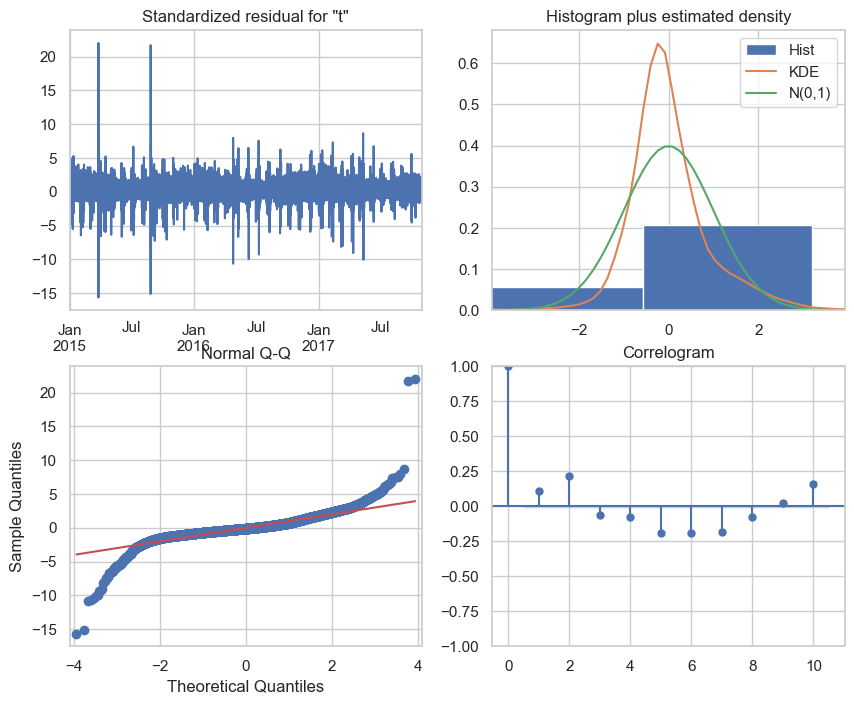

In [388]:
_ = SARIMAX_model_fit.plot_diagnostics(figsize = (10,8))

In [389]:
#Forecasting with the fitted model

sarimax_test_pred = SARIMAX_model_fit.predict(start=df_sarimax_test.index[0],
                                     end = df_sarimax_test.index[-1],
                                     exog = df_sarimax_test_exog.astype('float64'))

In [390]:
mape(df_sarimax_test, sarimax_test_pred)

np.float64(64.3030968431143)

The next plot is a visualisation of the result of the predictions compared to the actual data.

In [391]:
df_sarimax_test

timestamp
2017-11-01 00:00:00    28508.0
2017-11-01 01:00:00    26220.0
2017-11-01 02:00:00    24893.0
2017-11-01 03:00:00    24403.0
2017-11-01 04:00:00    24217.0
                        ...   
2018-03-31 20:00:00    26937.0
2018-03-31 21:00:00    29343.0
2018-03-31 22:00:00    28144.0
2018-03-31 23:00:00    26883.0
2018-04-01 00:00:00    26994.0
Name: total load actual, Length: 3625, dtype: float64

In [392]:
sarimax_test_pred

2017-11-01 00:00:00    24900.224279
2017-11-01 01:00:00    24071.205657
2017-11-01 02:00:00    23582.596573
2017-11-01 03:00:00    23295.563727
2017-11-01 04:00:00    23405.570338
                           ...     
2018-03-31 20:00:00     1407.031981
2018-03-31 21:00:00      375.893225
2018-03-31 22:00:00     -681.291057
2018-03-31 23:00:00    -1692.475503
2018-04-01 00:00:00    -2640.024021
Freq: h, Name: predicted_mean, Length: 3625, dtype: float64

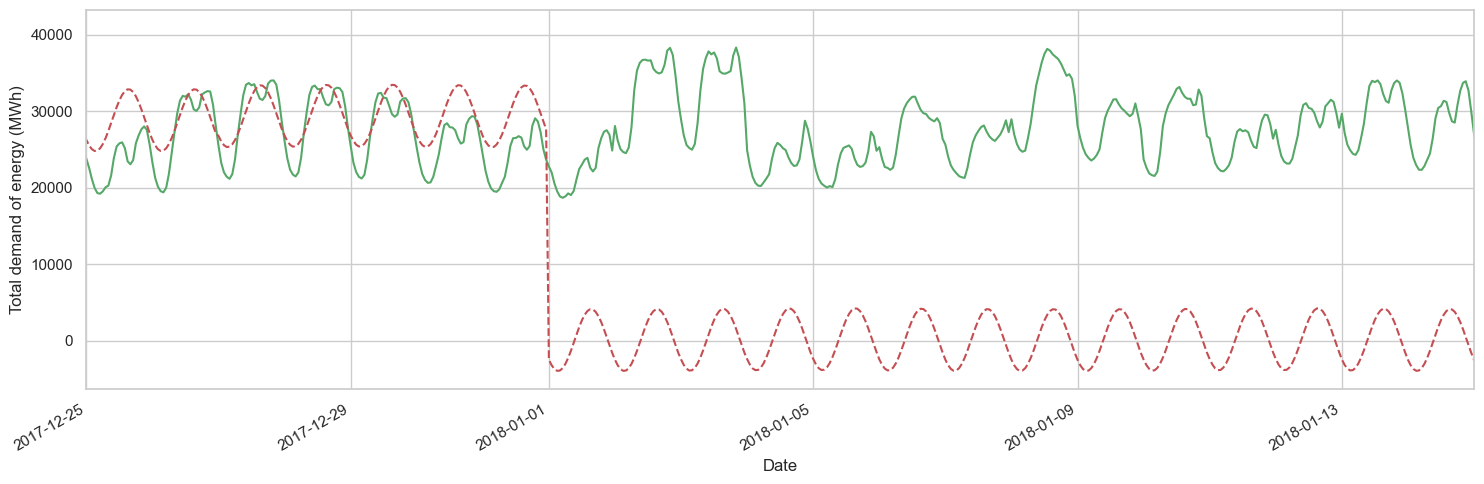

In [394]:
#Ploting our baselines in a graph
sns.set(rc={"figure.figsize":(15,5)})
sns.set_style('whitegrid')
fig, ax = plt.subplots()

ax.plot(df_sarimax_train.index, df_sarimax_train, 'b', label='Train')
ax.plot(df_sarimax_test.index, df_sarimax_test, 'g-', label='Test')
ax.plot(df_sarimax_test.index, sarimax_test_pred, 'r--', label='SARIMAX')

x_start = pd.to_datetime('2017-12-25 00:00:00')
x_end = pd.to_datetime('2018-01-15 00:00:00')
ax.set_xlim(x_start, x_end)

ax.set_xlabel('Date')
ax.set_ylabel('Total demand of energy (MWh)')

fig.autofmt_xdate()
plt.tight_layout()

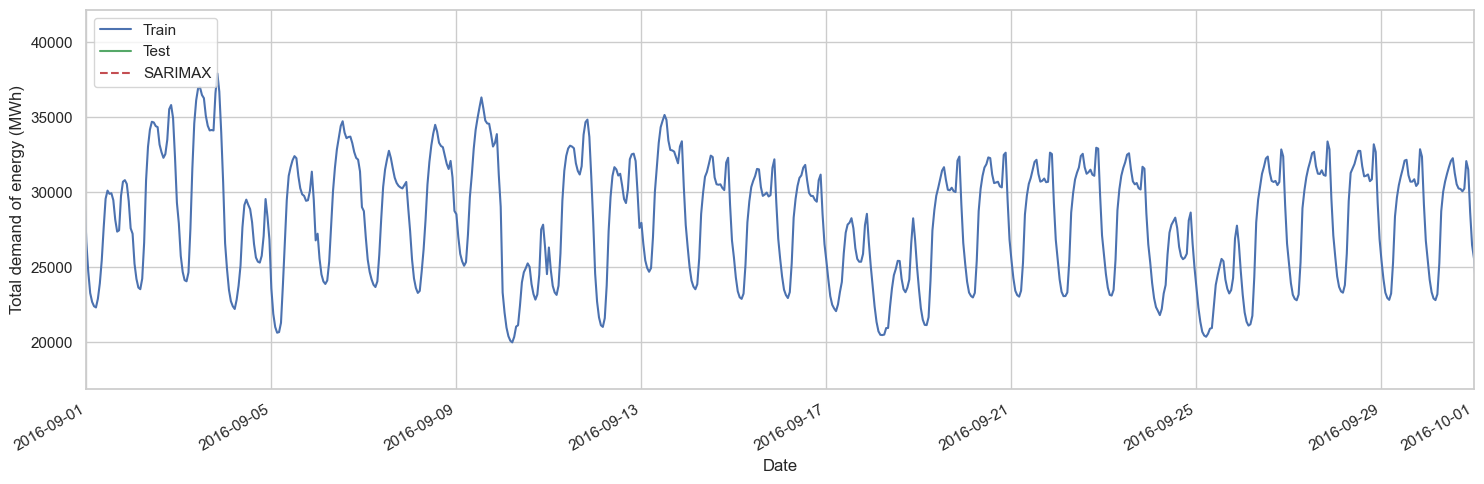

In [316]:
#Ploting our baselines in a graph
sns.set(rc={"figure.figsize":(15,5)})
sns.set_style('whitegrid')
fig, ax = plt.subplots()

ax.plot(df_sarimax_train.index, df_sarimax_train, 'b', label='Train')
ax.plot(df_sarimax_test.index, df_sarimax_test, 'g-', label='Test')
ax.plot(df_sarimax_test.index, sarimax_test_pred, 'r--', label='SARIMAX')

x_start = pd.to_datetime('2016-09-01 00:00:00')
x_end = pd.to_datetime('2016-10-01 00:00:00')
ax.set_xlim(x_start, x_end)


ax.set_xlabel('Date')
ax.set_ylabel('Total demand of energy (MWh)')
ax.axvspan('2018-12-17 23:00:00', '2019-01-01 00:00:00', color='#808080', alpha=0.2)
ax.legend(loc=2)

fig.autofmt_xdate()
plt.tight_layout()

Is it possible to verify that the model is having troubles to fit the data properly. Although the data predicted follows the shape of the test data, it does not follow the nuances of the weekly seasonality, in which weekdays' consume is higher weekend, or the yerly seasonality. 

In [125]:
#Adding SARIMAX method's MAPE

mape_results.loc[len(mape_results)] = ['SARIMAX_pred', mape(df_test['total load actual'], 
                                                              df_test['SARIMAX_pred'])]

In [126]:
mape_results.head()

,Method,MAPE
0,twoweekmean,16.667403
1,seasonal_naive,13.418538
2,seasonal_naive_last_year,5.414548
3,SARIMAX_pred,6.444268


It is possible to verify that Seasonal Naive using the same values from the same week on the past year outperforms by far SARIMAX.

The data will be fitted using a different method.